# Ranking Content Pages for Refresh Review Using Search Performance Signals
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsiddan25/program/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Which content pages should an SEO or content team review first for a possible refresh, using only search-performance information available before the outcome period?

Specifically, this study examines whether a Random Forest using February–April 2026 signals—such as impressions, CTR, search position, recent change, and volatility—can rank pages likely to experience more than a 20% decline in impressions during May 2026 more effectively than the Week-4 rule baseline.

The intended decision is prioritization: helping a reviewer decide which pages to investigate first when review capacity is limited. A high model score indicates measured decline risk, not proof that a page needs to be refreshed. Declining impressions may also reflect changes in search demand, competition, seasonality, or technical conditions, so all recommended pages require human review.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This study used the FlyRank internship warehouse release, build v20260703, hosted on Hugging Face. The full warehouse contains 78,835,655 daily performance rows covering January 27, 2025 through June 30, 2026. Each row in the primary source table, fact_content_daily_performance, represents one pseudonymized client’s content page on one report date.

The model analysis used the following windows:

February–April 2026 -  Feature and observation period

April 30, 2026  - Prediction cutoff

May 2026 - Future outcome and validation period

Daily records were aggregated into monthly page-level summaries. The final development dataset contained 62,558 unique client-page histories across 23 clients, with no duplicate client-page rows. To improve data comparability, each page was required to have at least 20 days of available GSC data in February, March, April, and May. Pages were also required to have positive March and April impressions so that percentage-change calculations had valid denominators.

Only rows where gsc_data_available was true were included. The model used search-performance information such as impressions, clicks, CTR, average position, recent changes, and daily volatility. May performance was used only to define the outcome and was not supplied to the model as a feature.

Client and content identifiers were retained only for grouping, validation, and connecting recommendations back to pages; they were not model inputs. Product-generated flags and scores were excluded to avoid circular predictions. GA4 signals, raw search queries, client names, and page URLs were not used. Content metadata such as staleness and word count was also excluded from the final model because earlier audits found substantial missingness.

All identifiers in the analysis are pseudonymized. No private client names, URLs, access tokens, or raw queries are included in the notebook, figures, or exported recommendations.


## 3. Methodology


**Task and assumptions**

This study treats content decline as a binary classification and ranking problem. The model assigns each eligible page a risk score, which is used to rank pages for manual review.

The approach makes three main assumptions:

Recent search-performance patterns contain information about near-term impression decline.

Monthly measurements are sufficiently comparable when pages have at least 20 observed GSC days per month.

A future impression decline is a useful review signal, but it is not proof that a page needs refreshing or that a refresh will improve performance.

The analysis measures predictive associations rather than causal effects.



**Features**

All model features were available by the April 30, 2026 prediction cutoff. Thirteen features were organized into four groups:

| Feature group | Variables |
|---|---|
| Traffic level | February–April impressions, March impressions, and April impressions |
| Recent momentum | March-to-April impression percentage change |
| CTR | March CTR, April CTR, and CTR change |
| Search position | March average position, April average position, and position change |
| Stability | April impression variation, position variation, and proportion of observed days with impressions |

Impression totals were log-transformed to reduce the influence of extremely high-traffic pages. March-to-April percentage change was limited to between −100% and 500% so unusually large growth rates caused by small starting values would not dominate the model. Average search position was calculated by weighting position by impressions. Missing numerical values were replaced with the training-set median.



**Label definition**

The outcome was whether a page experienced more than a 20% decline in impressions from April to May 2026:

$$
\text{Future decline} = 1
\quad \text{if} \quad
\text{May impressions} < 0.80 \times \text{April impressions}
$$

Pages that did not cross this threshold received a label of zero. The label is a proxy for decline risk, not a direct measurement of content quality or refresh need. The outcome base rate among eligible pages was 48.79%.

**Week-4 baseline**

The reference baseline flagged a page when:

it received at least 300 impressions in March, and

its impressions declined by more than 20% from March to April.

Qualifying pages were ranked by their absolute impression loss from March to April. Pages that did not meet both conditions received a baseline score of zero. This represents a simple, understandable rule that the machine-learning model must improve upon.

**Model**

Logistic Regression was first examined as a simple and interpretable classifier. A Random Forest was selected as the final model because it can represent nonlinear relationships and interactions among traffic, CTR, search position, and volatility.

The Random Forest used 200 trees, a maximum depth of 10, a minimum of 25 observations per leaf, balanced class weighting within each tree sample, and a fixed random seed of 42. Its class-one output was used as a ranking score. The score should be interpreted as relative decline risk rather than a perfectly calibrated probability.

**Validation design**

An initial five-fold random row validation was used as a “before” design. However, it placed pages belonging to the same clients in both training and validation data, creating between 21 and 23 overlapping clients per fold.

The final evaluation used five-fold stratified client-grouped cross-validation. All pages belonging to one client were kept together, and every validation prediction came from a model that had not trained on that client. Client overlap was zero in all five folds. Every page received one out-of-fold risk score, allowing the model and baseline to be evaluated on the same 62,558 pages.

Precision@20 was the primary metric because the intended output is a small human-review queue. Precision@50, Precision@100, average precision, ROC AUC, and the outcome base rate were also reported.

May was used for label construction, threshold assessment, and model validation. Therefore, May is a development and validation period rather than an untouched final test period.

**Leakage checks**

The leakage audit confirmed that the 13 model features contained no May performance, outcome-derived columns, client or content identifiers, or FlyRank-generated flags and scores. It also checked for features that exactly copied the target, differences between training and validation columns, and client overlap between grouped folds.

No structural leakage was detected, and every grouped fold had zero client overlap. However, eligibility required at least 20 observed GSC days in May. May availability therefore influenced which pages were evaluated, even though May performance was not used as a model feature.

## 4. Results (vs baseline)

The Week-4 baseline and Random Forest were evaluated on the same 62,558 eligible client-page histories. The Random Forest results below use client-grouped out-of-fold predictions, meaning each page was scored by a model that had not trained on pages from that client. The outcome base rate was 48.79%.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Verified results from the Week-6 validation notebook
results_table = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Random Forest (client-grouped)",
    ],
    "Base rate (%)": [48.79, 48.79],
    "Precision@20 (%)": [75.00, 95.00],
    "Precision@50 (%)": [66.00, 96.00],
    "Precision@100 (%)": [73.00, 98.00],
    "Average precision (%)": [56.13, 75.62],
    "ROC AUC (%)": [59.71, 75.31],
})

display(results_table)

,Method,Base rate (%),Precision@20 (%),Precision@50 (%),Precision@100 (%),Average precision (%),ROC AUC (%)
0,Week-4 baseline,48.79,75.0,66.0,73.0,56.13,59.71
1,Random Forest (client-grouped),48.79,95.0,96.0,98.0,75.62,75.31


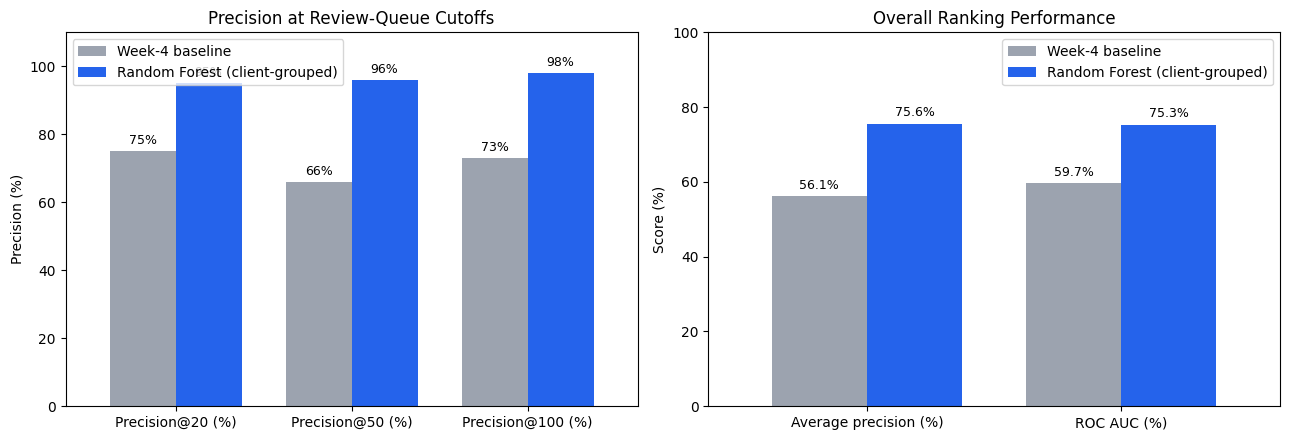

Figure saved to: work/figures/model_vs_baseline.png


In [2]:
figure_dir = Path("work/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ["#9CA3AF", "#2563EB"]

# Precision@K chart
precision_data = (
    results_table
    .set_index("Method")[
        [
            "Precision@20 (%)",
            "Precision@50 (%)",
            "Precision@100 (%)",
        ]
    ]
    .T
)

precision_data.plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    width=0.75,
)

axes[0].set_title("Precision at Review-Queue Cutoffs")
axes[0].set_xlabel("")
axes[0].set_ylabel("Precision (%)")
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.0f%%",
        padding=3,
        fontsize=9,
    )

# Overall ranking metrics chart
ranking_data = (
    results_table
    .set_index("Method")[
        [
            "Average precision (%)",
            "ROC AUC (%)",
        ]
    ]
    .T
)

ranking_data.plot(
    kind="bar",
    ax=axes[1],
    color=colors,
    width=0.75,
)

axes[1].set_title("Overall Ranking Performance")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9,
    )

fig.tight_layout()

figure_path = figure_dir / "model_vs_baseline.png"
fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path}")

## 5. Limitations

*What this work cannot claim.*

### **Interpretation**

The client-grouped Random Forest outperformed the Week-4 baseline on every reported aggregate metric. Among the top 20 pages, 19 experienced the defined May decline, compared with 15 of the baseline’s top 20. At 50 pages, the model correctly prioritized 48 declining pages compared with 33 for the baseline. At 100 pages, the corresponding counts were 98 and 73.

Average precision increased from 56.13% to 75.62%, an improvement of 19.49 percentage points. ROC AUC increased from 59.71% to 75.31%, an improvement of 15.60 percentage points. These results indicate that search position, CTR, traffic level, and volatility added useful ranking information beyond the baseline’s recent-impression-decline rule.

Random row validation produced average precision of 78.88% and ROC AUC of 78.62%. These values decreased to 75.62% and 75.31% under client-grouped validation, suggesting that random row validation provided a mildly optimistic estimate because clients overlapped between training and validation.

The grouped results provide evidence that the model can support review prioritization for eligible pages from the observed client population. However, the metrics are page-weighted, clients contributed very different numbers of pages, and performance was not equal across every client. The results do not establish that the model will perform equally on new time periods or that refreshing a selected page will recover impressions.

## 6. Ranked recommendations

The model ranked all 62,558 eligible pages by relative decline risk. Because manual review capacity is limited, the first recommended action is to review the top 20 pages. The ranking determines which pages should be examined first; it does not automatically determine that a page should be refreshed.

Each page receives one primary reason code based on an observable pre-May signal. The reason code makes the recommendation easier to investigate, but it should not be interpreted as a complete explanation of the model’s score or the cause of decline.

Within the top-20 review batch, 19 pages showed a March-to-April impression decline greater than 20%. One page had unusually volatile daily impressions despite increasing from March to April. The second case is especially important: a high model score can indicate instability even when the most recent monthly total increased.

In [3]:
import pandas as pd

# Composition of the complete top-20 review batch
top_20_summary = pd.DataFrame({
    "Reason code": [
        "recent_impression_decline",
        "high_impression_volatility",
    ],
    "Pages in top 20": [19, 1],
    "Share of top 20 (%)": [95.0, 5.0],
    "Suggested action": [
        "Review for possible refresh",
        "Diagnose traffic instability",
    ],
})

display(top_20_summary)

,Reason code,Pages in top 20,Share of top 20 (%),Suggested action
0,recent_impression_decline,19,95.0,Review for possible refresh
1,high_impression_volatility,1,5.0,Diagnose traffic instability


In [4]:
action_mapping_table = pd.DataFrame({
    "Reason code": [
        "recent_impression_decline",
        "high_impression_volatility",
        "worsening_search_position",
        "high_position_volatility",
        "high_visibility_at_risk",
        "elevated_model_risk",
    ],
    "Suggested human action": [
        "Review content freshness, accuracy, and search intent",
        "Investigate whether traffic changes are temporary or unstable",
        "Review search results, relevance, and competing pages",
        "Investigate inconsistent rankings before changing content",
        "Prioritize manual review because substantial visibility is at risk",
        "Perform a broader manual investigation",
    ],
})

display(action_mapping_table)

,Reason code,Suggested human action
0,recent_impression_decline,"Review content freshness, accuracy, and search..."
1,high_impression_volatility,Investigate whether traffic changes are tempor...
2,worsening_search_position,"Review search results, relevance, and competin..."
3,high_position_volatility,Investigate inconsistent rankings before chang...
4,high_visibility_at_risk,Prioritize manual review because substantial v...
5,elevated_model_risk,Perform a broader manual investigation


In [5]:
top_ranked_examples = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5],
    "Model risk score": [
        0.973374,
        0.973020,
        0.972297,
        0.971355,
        0.971314,
    ],
    "Action": [
        "Review for possible refresh",
        "Review for possible refresh",
        "Review for possible refresh",
        "Review for possible refresh",
        "Review for possible refresh",
    ],
    "Reason": [
        "April impressions were 47.7% lower than March",
        "April impressions were 50.7% lower than March",
        "April impressions were 41.1% lower than March",
        "April impressions were 61.2% lower than March",
        "April impressions were 39.2% lower than March",
    ],
})

display(top_ranked_examples)

,Rank,Model risk score,Action,Reason
0,1,0.973374,Review for possible refresh,April impressions were 47.7% lower than March
1,2,0.973020,Review for possible refresh,April impressions were 50.7% lower than March
2,3,0.972297,Review for possible refresh,April impressions were 41.1% lower than March
3,4,0.971355,Review for possible refresh,April impressions were 61.2% lower than March
4,5,0.971314,Review for possible refresh,April impressions were 39.2% lower than March


**Recommended Review Process**

For each selected page, the reviewer should:

Confirm that the page is still published, indexable, and strategically valuable.

Verify that the decline is not caused by missing GSC data or a technical tracking problem.

Examine search demand, seasonality, ranking movement, competing results, and recent content changes.

Decide whether the appropriate response is a content refresh, technical correction, continued monitoring, or no action.

Record the decision and later outcome so future recommendations can be evaluated.

Recent impression decline is a useful prioritization signal, but it does not prove that content has decayed. Ranking changes may reflect competition or relevance, while impression volatility may reflect seasonality or unstable demand. The model therefore supports investigation rather than automatic action.

The full ranked queue is regenerated by w07_action_playbook.ipynb. Client and content identifiers are omitted from the public examples above, while the underlying notebook retains pseudonymized identifiers for reproducibility.

## 7. Artifacts the paper embeds

The deployed paper uses a small set of public-safe artifacts:

A model-versus-baseline results table.

A chart comparing Precision@20, Precision@50, and Precision@100.

A chart comparing average precision and ROC AUC.

A validation-design chart comparing random row and client-grouped validation.

A summary of the top-20 review batch.

A reason-code-to-action mapping.

A public-safe excerpt of the five highest-ranked recommendations.

These artifacts contain only aggregate results or anonymized examples. They do not contain client names, page URLs, raw queries, access tokens, or May outcome values for individual pages.

,Validation design,Average precision (%),ROC AUC (%)
0,Random row,78.88,78.62
1,Client-grouped,75.62,75.31


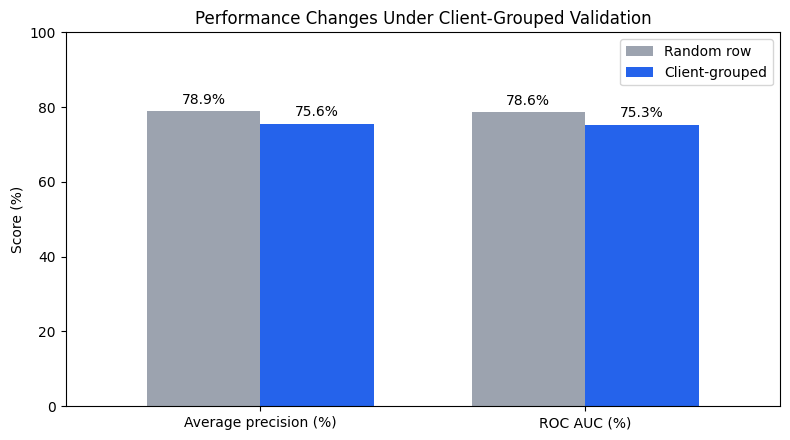

Figure saved to: work/figures/validation_design_comparison.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = Path("work/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

validation_design_table = pd.DataFrame({
    "Validation design": [
        "Random row",
        "Client-grouped",
    ],
    "Average precision (%)": [
        78.88,
        75.62,
    ],
    "ROC AUC (%)": [
        78.62,
        75.31,
    ],
})

display(validation_design_table)

ax = (
    validation_design_table
    .set_index("Validation design")
    .T
    .plot(
        kind="bar",
        figsize=(8, 4.5),
        color=["#9CA3AF", "#2563EB"],
        width=0.70,
    )
)

ax.set_title("Performance Changes Under Client-Grouped Validation")
ax.set_xlabel("")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

plt.tight_layout()

validation_figure_path = (
    figure_dir / "validation_design_comparison.png"
)

plt.savefig(
    validation_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {validation_figure_path}")

**Validation-design takeaway:** Average precision decreased from 78.88% to 75.62%, and ROC AUC decreased from 78.62% to 75.31%, after pages were grouped by client. This suggests that random row validation produced a mildly optimistic estimate by allowing client overlap.

In [7]:
import json

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

paper_metrics = {
    "evaluation_rows": 62558,
    "evaluation_clients": 23,
    "feature_window": "2026-02-01 to 2026-04-30",
    "outcome_window": "2026-05-01 to 2026-05-31",
    "outcome_base_rate_pct": 48.79,
    "primary_metric": "Precision@20",
    "primary_validation": (
        "5-fold stratified client-grouped cross-validation"
    ),
    "results": results_table.to_dict(orient="records"),
}

metrics_path = output_dir / "capstone_metrics.json"

with open(metrics_path, "w") as file:
    json.dump(
        paper_metrics,
        file,
        indent=2,
    )

print(f"Metrics saved to: {metrics_path}")

Metrics saved to: work/outputs/capstone_metrics.json


In [8]:
artifact_inventory = pd.DataFrame({
    "Artifact": [
        "Model vs. baseline charts",
        "Validation-design chart",
        "Aggregate metrics receipt",
    ],
    "Path": [
        "work/figures/model_vs_baseline.png",
        "work/figures/validation_design_comparison.png",
        "work/outputs/capstone_metrics.json",
    ],
    "Purpose": [
        "Show model improvement over the baseline",
        "Show the effect of more honest validation",
        "Record the paper's reported metrics",
    ],
})

artifact_inventory["File exists"] = (
    artifact_inventory["Path"]
    .apply(lambda path: Path(path).exists())
)

display(artifact_inventory)

assert artifact_inventory["File exists"].all(), (
    "At least one artifact is missing. "
    "Rerun the corresponding chart or export cell."
)

print("PASS: All paper artifacts were generated.")

,Artifact,Path,Purpose,File exists
0,Model vs. baseline charts,work/figures/model_vs_baseline.png,Show model improvement over the baseline,True
1,Validation-design chart,work/figures/validation_design_comparison.png,Show the effect of more honest validation,True
2,Aggregate metrics receipt,work/outputs/capstone_metrics.json,Record the paper's reported metrics,True


PASS: All paper artifacts were generated.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
